In [19]:
import pandas as pd
import csv
import pickle
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import os
import random
from itertools import product


from stage1 import lasso_rolling_window, calculate_r_squared
from stage2 import estimate_kappa_curve_fit, compute_alm_returns, compute_stage2_r_squared
from grid_search import grid_search

In [20]:
# load feature matrix and response variable
feature_matrix = pd.read_csv(r"C:\Users\jonat\Lasso_paper\Empirical\data\merged_return_topic_data.csv", index_col=0, parse_dates=True)
response_variables = pd.read_csv(r"C:\Users\jonat\Lasso_paper\Empirical\data\response.csv", index_col=0, parse_dates=True)

In [25]:
# select a response variable (either marekt return or sp500 return)
y = response_variables['vwretx']  # or 'sprtrn' for SP500 returns
# transform returns to log
y = np.log(y+1)

# create feature matrix
X = feature_matrix.copy()
random.seed(42)

# Separate topic (name) and stock (numeric) columns
topic_cols = [col for col in X.columns if not str(col).isdigit()]
stock_cols = [col for col in X.columns if str(col).isdigit()]

# User-selected number of each (or use len(...) for "all")
num_topics = 10
num_stocks = 50

# Randomly sample (without replacement), limited by available count
selected_topics = random.sample(topic_cols, min(num_topics, len(topic_cols)))
selected_stocks = random.sample(stock_cols, min(num_stocks, len(stock_cols)))

# Final filtered dataframe
X = X[selected_topics + selected_stocks]

# Convert stock returns to log returns: log(1+r)
X[selected_stocks] = np.log(X[selected_stocks] + 1)

# ensure that all indices align
common_index = X.index.intersection(y.index)
X = X.loc[common_index]
y = y.loc[common_index]

In [22]:
print(X.head(2))

             Buffett  Music industry   Changes  Aerospace/defense    Drexel  \
date                                                                          
2010-01-04  0.004151        0.002820  0.006971           0.002661  0.001969   
2010-01-05  0.004448        0.002302  0.006489           0.004657  0.003349   

              Pharma  Revised estimate  Activists    Mexico  Bear/bull market  \
date                                                                            
2010-01-04  0.000851          0.004896   0.004417  0.006226          0.011176   
2010-01-05  0.016588          0.003035   0.003715  0.003401          0.005808   

            ...     18649     91801     84385     87842     40272     79663  \
date        ...                                                               
2010-01-04  ...  0.023951  0.024244  0.020974  0.026519  0.020927  0.027306   
2010-01-05  ... -0.017807  0.030938 -0.001661  0.022877 -0.007406  0.011332   

               25304     88853     75938 

In [26]:
# Cell in your notebook
param_grid = {
    'window_sizes': [30],
    'n_lags': [1,2],
    'lambdas': [0.001]
}

summary_df, coefficients_df = grid_search(X, y, param_grid, verbose=True)

Testing 2 configurations...


Grid search: 100%|██████████| 2/2 [00:00<00:00, 1423.97it/s]



GRID SEARCH COMPLETE


In [ ]:
print

In [ ]:
# Define your grid
param_grid = {
    'window_sizes': [30,60,100,200,300,500],
    'n_lags': [1,2,3,5,8],
    'lambdas': [0.01,0.001,0.0001,0.00001,0.000005,0.000001]
}

# Run grid search 
results_df1 = grid_search(X, y, param_grid, verbose=True)

# Save
results_df1.to_csv('grid_search_results8.csv', index=False)

In [ ]:
grid_results = pd.read_csv("grid_search_results5.csv")

In [ ]:
print(grid_results.head(10))

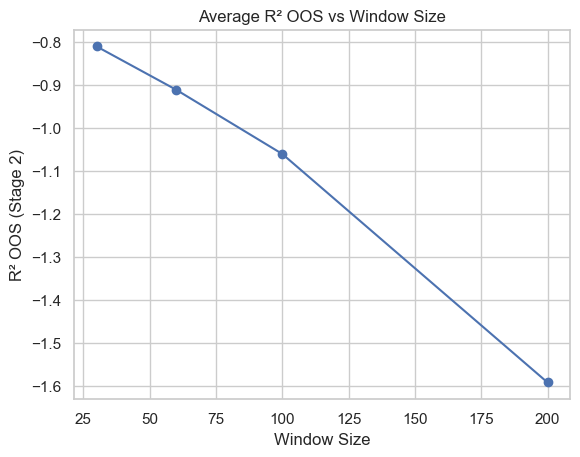

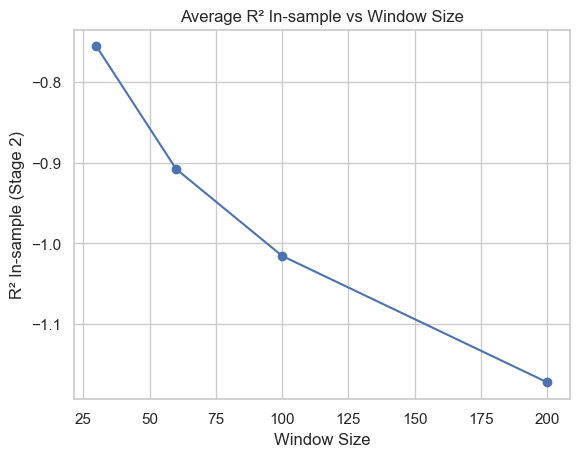

In [16]:
# Compute average metrics per window size
avg = grid_results.groupby('window_size', as_index=False)[
    ['r2_oos_stage2', 'r2_insample_stage2']
].mean()

# Plot Avg R2 OOS vs window size
plt.figure()
plt.plot(avg['window_size'], avg['r2_oos_stage2'], marker='o')
plt.xlabel('Window Size')
plt.ylabel('R² OOS (Stage 2)')
plt.title('Average R² OOS vs Window Size')
plt.grid(True)
plt.show()

# Plot Avg R2 In-sample vs window size
plt.figure()
plt.plot(avg['window_size'], avg['r2_insample_stage2'], marker='o')
plt.xlabel('Window Size')
plt.ylabel('R² In-sample (Stage 2)')
plt.title('Average R² In-sample vs Window Size')
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Plot R2 oos stage2 vs lambda
plt.figure()
plt.scatter(grid_results['window_size'], grid_results['r2_oos_stage2'])
# plt.xscale('log')
plt.xlabel('lambda (log scale)')
plt.ylabel('R² (OOS stage 2)')
plt.title('R² vs lambda (log scale)')
plt.show()

# Plot R2 in sample stage2 vs lambda
plt.figure()
plt.scatter(grid_results['window_size'], grid_results['r2_insample_stage2'])
# plt.xscale('log')
plt.xlabel('lambda (log scale)')
plt.ylabel('R² (OOS stage 2)')
plt.title('R² vs lambda (log scale)')
plt.show()

# Plot kappa vs lambda
plt.figure()
plt.scatter(grid_results['lambda'], grid_results['kappa'])
plt.xscale('log')
plt.xlabel('lambda (log scale)')
plt.ylabel('kappa')
plt.title('Kappa vs lambda (log scale)')
plt.show()


In [ ]:
metrics = grid_results[['lambda', 'n_lags', 'window_size']].corrwith(grid_results['kappa']).abs()
print(metrics.sort_values(ascending=False))